In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
from agents import Agent, function_tool
from agents.mcp.server import MCPServerStdio
from agents.extensions.visualization import draw_graph

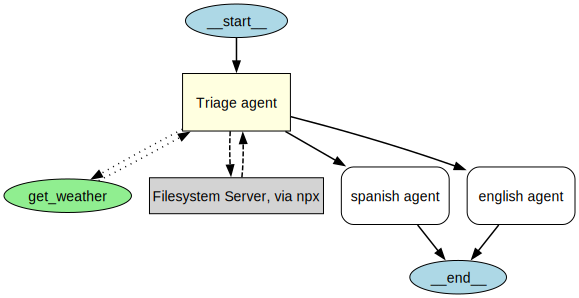

In [4]:
@function_tool
def get_weather(city:str)->str:
    return f"The weather in {city} in sunny."

spanish_agent=Agent(name="spanish agent",instructions="you only speak spanish.",model="gpt-5-nano")
english_agent=Agent(name="english agent",instructions="you only speak english.",model="gpt-5-nano")

current_dir = os.getcwd()
samples_dir=os.path.join(current_dir,"sample_files")
mcp_server=MCPServerStdio(name="Filesystem Server, via npx",
                          params={
                              "command":"npx",
                              "args":["-y", "@modelcontextprotocol/server-filesystem", samples_dir]
                          })
triage_agent=Agent(name="Triage agent",
                   instructions="handoff to the appropriate agent based on the Language of the request",
                   handoffs=[spanish_agent,english_agent],
                   tools=[get_weather],
                   mcp_servers=[mcp_server])
draw_graph(triage_agent)


In [5]:
draw_graph(triage_agent).view()

'Source.gv.pdf'

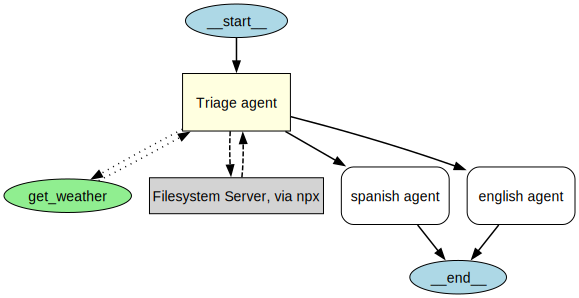

In [6]:
draw_graph(triage_agent, filename="agent_graph")

In [ ]:
# Agents
import asyncio
import random
from agents import Agent, function_tool
from agents.extensions.handoff_prompt import prompt_with_handoff_instructions

@function_tool
def get_weather(city:str)->str:
    """Get the weather for a given city."""
    print(f"[debug] get_weather called with city: {city}")
    choices=["sunny","cloudy","rainy","snowy"]
    return f"The Weather in {city} is {random.choice(choices)}."

spanish_agent=Agent(
    name="spanish agent",
    handoff_description="A spanish speaking agent.",
    instructions=prompt_with_handoff_instructions(
        "You're speaking to a human, so be polite and "
    )
)